In [1]:
# import packages
import numpy as np
import pandas as pd
import xarray as xr
import netCDF4 as nc
import glob
import matplotlib.pyplot as plt
import cfgrib
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors

# MOSAiC Track

In [ ]:
# Full Track
track = pd.read_csv('/proj/naiss2024-22-523/Polar_hackathon/Code/MOSAiC_track_1h.txt', sep=r'\s+')
track = track.rename(columns={'Datetime':'time_raw','Latitude':'lat','Longitude':'lon'})
track['time'] = pd.to_datetime(track['time_raw'].astype(str), format='%Y%m%d%H')
track['lon'] = ((track['lon']+180.0)%360.0)-180.0
track['date_str'] = track['time'].dt.strftime('%Y%m%d')
track['time_str'] = track['time'].dt.strftime('%H%M')
display(track)

# Select specific time period if it is needed
mask = (track['time'] >= '2020-02-01') & (track['time'] <= '2020-04-30')
df_track_sel = track[mask]

# Just helping to select region for CARRA2/IFS-FESOM region
print(df_track_sel['lat'].min(), df_track_sel['lat'].max(), df_track_sel['lon'].min(), df_track_sel['lon'].max())

# Read MOSAiC file

In [2]:
ds_mosaic = xr.open_dataset('/proj/naiss2024-22-523/Polar_hackathon/Data/MOSAiC_obs_combined_1h_v2.nc').sel(time=slice("2020-02-01", "2020-04-30"))
ds_mosaic

<xarray.Dataset> Size: 16MB
Dimensions:                    (time: 2160, height: 596)
Coordinates:
  * time                       (time) datetime64[ns] 17kB 2020-02-01 ... 2020...
  * height                     (height) float32 2kB 160.0 190.0 ... 1.801e+04
Data variables: (12/54)
    lat                        (time) float64 17kB ...
    lon                        (time) float64 17kB ...
    temp_2m                    (time) float64 17kB ...
    temp_6m                    (time) float64 17kB ...
    temp_10m                   (time) float64 17kB ...
    skin_temp_surface          (time) float64 17kB ...
    ...                         ...
    up_long_hemisp_mean        (time) float64 17kB ...
    down_short_hemisp_mean     (time) float64 17kB ...
    up_short_hemisp_mean       (time) float64 17kB ...
    lwc                        (time, height) float32 5MB ...
    iwc                        (time, height) float32 5MB ...
    temperature                (time, height) float32 5MB ...

In [3]:
track_from_ds = pd.DataFrame({
    "lat": ds_mosaic.lat.to_series(),
    "lon": ds_mosaic.lon.to_series(),
})

In [4]:
# Extract variables
obs_t2m = ds_mosaic.temp_2m.to_series()
obs_10si = ds_mosaic.wspd_vec_mean_10m.to_series()          

# Read Leads file

The ArcLeads dataset contains daily maps with categories: 0=clouds, 1=land, 2=sea ice, 3=artefacts, 4=leads, 5=open water.

In [ ]:
ds_leads = xr.open_dataset('/proj/naiss2024-22-523/Polar_hackathon/Data/201920_ArcLeads.nc')
ds_leads

In [ ]:
# Change the time format in ds
new_time = pd.to_datetime(ds_leads.time.values, format='%Y%m%d')
ds_leads = ds_leads.assign_coords(time=new_time)
ds_leads_sel = ds_leads.sel(time=slice('2020-02-01', '2020-04-30'))

# Limit the leads file region 
lat_min, lat_max = 80, 90
lon_min, lon_max = 0, 100

mask = ((ds_leads_sel.lat >= lat_min) & (ds_leads_sel.lat <= lat_max) &
        (ds_leads_sel.lon >= lon_min) & (ds_leads_sel.lon <= lon_max))

rows, cols = np.where(mask.values)
row_min, row_max = rows.min(), rows.max()
col_min, col_max = cols.min(), cols.max()

ds_leads_track = ds_leads_sel.isel(
    nrows=slice(row_min, row_max + 1),
    ncols=slice(col_min, col_max + 1))

print(ds_leads_track)

# Leads map plot

In [ ]:
lon = ds_leads_track.lon
lat = ds_leads_track.lat
map_loc = ds_leads_track.leadmap

colors = [
    "lightgrey",    # 0 clouds 
    "tan",          # 1 land
    "white",        # 2 sea ice
    "slategrey",    # 3 artefacts
    "deeppink",         # 4 leads
    "navy",         # 5 open water
]
labels = ["Clouds", "Land", "Sea ice", "Artefacts", "Leads", "Open water"]

cmap = mcolors.ListedColormap(colors)
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5]  
norm = mcolors.BoundaryNorm(bounds, cmap.N)

fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=ccrs.NorthPolarStereo())
ax.set_extent([-30, 120, 75, 90], ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="0.85")
ax.coastlines(resolution="50m", linewidth=0.5)
ax.gridlines(draw_labels=False, linewidth=0.3)

mesh = ax.pcolormesh(
    lon, lat, map_loc[12],
    cmap=cmap, norm=norm,
    transform=ccrs.PlateCarree()
)

ax.scatter(df_track_sel['lon'],df_track_sel['lat'],transform=ccrs.PlateCarree(),
           s=5, color='orange',zorder=5)

cbar = plt.colorbar(mesh, ax=ax, orientation="vertical", aspect=30, shrink=0.8, pad=0.08)
cbar.set_ticks([0, 1, 2, 3, 4, 5])
cbar.set_ticklabels(labels)

plt.show()

# Overlap MOSAiC Ship track and leads map

In [ ]:
lat_grid = ds_leads_track.lat.values
lon_grid = ds_leads_track.lon.values
leadmap = ds_leads_track.leadmap.values     
time_vals = ds_leads_track.time.values       

df_track_sel = df_track_sel.reset_index(drop=True)

def nearest_index(lat0, lon0, lat2d, lon2d):
    """Index of the grid point closest to (lat0, lon0), great-circle distance."""
    la, lo = np.radians(lat2d), np.radians(lon2d)
    d = np.arccos(np.clip(
        np.sin(np.radians(lat0)) * np.sin(la)
        + np.cos(np.radians(lat0)) * np.cos(la) * np.cos(lo - np.radians(lon0)),
        -1, 1))
    return np.unravel_index(np.nanargmin(d), d.shape)

vals, dists = [], []
for i in range(len(df_track_sel)):
    lat0 = df_track_sel['lat'].iloc[i]
    lon0 = df_track_sel['lon'].iloc[i]
    t0 = pd.to_datetime(df_track_sel['time'].iloc[i]).floor('D')

    if np.isnan(lat0) or np.isnan(lon0):
        vals.append(np.nan); dists.append(np.nan); continue

    iy, ix = nearest_index(lat0, lon0, lat_grid, lon_grid)

    # match track's date to the correct daily leadmap layer
    it = np.searchsorted(time_vals, np.datetime64(t0))
    it = np.clip(it, 0, len(time_vals) - 1)

    vals.append(float(leadmap[it, iy, ix]))
    dists.append(6371.0 * np.arccos(np.clip(
        np.sin(np.radians(lat0)) * np.sin(np.radians(lat_grid[iy, ix]))
        + np.cos(np.radians(lat0)) * np.cos(np.radians(lat_grid[iy, ix]))
        * np.cos(np.radians(lon_grid[iy, ix] - lon0)), -1, 1)))

df_track_sel['leadmap_val'] = vals
df_track_sel['dist_km'] = dists
display(df_track_sel)

# Plot the overlap result

In [ ]:
from matplotlib.colors import ListedColormap, BoundaryNorm

colors = [
    "lightgrey",   # 0 clouds
    "tan",         # 1 land
    "white",       # 2 sea ice
    "slategrey",   # 3 artefacts
    "deeppink",         # 4 leads
    "navy",        # 5 open water
]

cmap = ListedColormap(colors)
bounds = np.arange(-0.5, len(colors) + 0.5, 1) 
norm = BoundaryNorm(bounds, cmap.N)

fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=ccrs.NorthPolarStereo())
ax.set_extent([-30, 120, 75, 90], ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="0.85")
ax.coastlines(resolution="50m", linewidth=0.5)
ax.gridlines(draw_labels=False, linewidth=0.3)

df_sorted = df_track_sel.sort_values(by='leadmap_val', key=lambda x: (x == 4).astype(int))

mesh = ax.scatter(
    df_sorted['lon'], df_sorted['lat'],
    c=df_sorted['leadmap_val'],
    cmap=cmap,
    norm=norm,
    transform=ccrs.PlateCarree(),
    s=10,
    zorder=5
)

cbar = plt.colorbar(mesh, ax=ax, ticks=range(len(colors)), aspect=30, shrink=0.8)
cbar.ax.set_yticklabels(['clouds', 'land', 'sea ice', 'artefacts', 'leads', 'open water'])
plt.show()

# Read CARRA2 forecast hourly files

In [ ]:
# Read CARRA2 data
# Feb
carra2_t2m_feb = xr.open_dataset('/proj/naiss2024-22-523/Polar_hackathon/Code/CARRA2/forecast_hourly/2m_temp/carra2_forecast_t2m_hourly_202002.nc')
carra2_10si_feb = xr.open_dataset('/proj/naiss2024-22-523/Polar_hackathon/Code/CARRA2/forecast_hourly/10m_wind/carra2_forecast_10si_hourly_202002.nc')

# Mar
carra2_t2m_mar = xr.open_dataset('/proj/naiss2024-22-523/Polar_hackathon/Code/CARRA2/forecast_hourly/2m_temp/carra2_forecast_t2m_hourly_202003.nc')
carra2_10si_mar = xr.open_dataset('/proj/naiss2024-22-523/Polar_hackathon/Code/CARRA2/forecast_hourly/10m_wind/carra2_forecast_10si_hourly_202003.nc')

# Apr
carra2_t2m_apr = xr.open_dataset('/proj/naiss2024-22-523/Polar_hackathon/Code/CARRA2/forecast_hourly/2m_temp/carra2_forecast_t2m_hourly_202004.nc')
carra2_10si_apr = xr.open_dataset('/proj/naiss2024-22-523/Polar_hackathon/Code/CARRA2/forecast_hourly/10m_wind/carra2_forecast_10si_hourly_202004.nc')

In [ ]:
lat2d = carra_t2m_hourly.latitude.values
lon2d = (carra_t2m_hourly.longitude.values + 180) % 360 - 180   # ensure -180..180
box = (lat2d > 80) & (lat2d < 90) & (lon2d > 0) & (lon2d < 100)
jy, jx = np.where(box)
carra = carra_t2m_hourly.isel(y=slice(jy.min(), jy.max() + 1), x=slice(jx.min(), jx.max() + 1))

c_t2m = carra.t2m.load()                     # cropped -> fits in memory
c_lat = carra.latitude.values
c_lon = (carra.longitude.values + 180) % 360 - 180
c_times = pd.DatetimeIndex(carra.time.values)
timen = "time"
print(f"cropped grid: {c_lat.shape}, {c_times[0]} .. {c_times[-1]} ({len(c_times)} analyses)")


def nearest_index(lat0, lon0, lat2d, lon2d):
    """Index of the grid point closest to (lat0, lon0), great-circle distance."""
    la, lo = np.radians(lat2d), np.radians(lon2d)
    d = np.arccos(np.clip(
        np.sin(np.radians(lat0)) * np.sin(la)
        + np.cos(np.radians(lat0)) * np.cos(la) * np.cos(lo - np.radians(lon0)),
        -1, 1))
    return np.unravel_index(np.nanargmin(d), d.shape)


# # track position at each CARRA2 analysis time (track is hourly -> exact matches)
# pos = track.reindex(c_times, method="nearest", tolerance=pd.Timedelta("1h"))

vals, dists = [], []
spatial_dims = [d for d in c_t2m.dims if d != timen]
for i, t in enumerate(c_times):
    if np.isnan(df_track_sel["lat"].iloc[i]):
        vals.append(np.nan); dists.append(np.nan); continue
    iy, ix = nearest_index(df_track_sel["lat"].iloc[i], df_track_sel["lon"].iloc[i], c_lat, c_lon)
    vals.append(float(c_t2m.isel({timen: i, spatial_dims[0]: iy, spatial_dims[1]: ix})))
    dists.append(6371.0 * np.arccos(np.clip(
        np.sin(np.radians(df_track_sel['lat'].iloc[i])) * np.sin(np.radians(c_lat[iy, ix]))
        + np.cos(np.radians(df_track_sel['lat'].iloc[i])) * np.cos(np.radians(c_lat[iy, ix]))
        * np.cos(np.radians(c_lon[iy, ix] - df_track_sel['lon'].iloc[i])), -1, 1)))


In [5]:
import numpy as np
import pandas as pd
import xarray as xr
from scipy.spatial import cKDTree

# Read all CARRA2 files
t2m_paths = [
    "/proj/naiss2024-22-523/Polar_hackathon/Code/CARRA2/forecast_hourly/2m_temp/carra2_forecast_t2m_hourly_202002.nc",
    "/proj/naiss2024-22-523/Polar_hackathon/Code/CARRA2/forecast_hourly/2m_temp/carra2_forecast_t2m_hourly_202003.nc",
    "/proj/naiss2024-22-523/Polar_hackathon/Code/CARRA2/forecast_hourly/2m_temp/carra2_forecast_t2m_hourly_202004.nc",
]
si_paths = [
    "/proj/naiss2024-22-523/Polar_hackathon/Code/CARRA2/forecast_hourly/10m_wind/carra2_forecast_10si_hourly_202002.nc",
    "/proj/naiss2024-22-523/Polar_hackathon/Code/CARRA2/forecast_hourly/10m_wind/carra2_forecast_10si_hourly_202003.nc",
    "/proj/naiss2024-22-523/Polar_hackathon/Code/CARRA2/forecast_hourly/10m_wind/carra2_forecast_10si_hourly_202004.nc",
]

carra_t2m_hourly = xr.open_mfdataset(t2m_paths, combine="by_coords").sortby("time")
carra_10si_hourly = xr.open_mfdataset(si_paths, combine="by_coords").sortby("time")


def crop_to_box(ds, lat_min=80, lat_max=90, lon_min=0, lon_max=100):
    lat2d = ds.latitude.values
    lon2d = (ds.longitude.values + 180) % 360 - 180
    box = (lat2d > lat_min) & (lat2d < lat_max) & (lon2d > lon_min) & (lon2d < lon_max)
    jy, jx = np.where(box)
    return ds.isel(y=slice(jy.min(), jy.max() + 1), x=slice(jx.min(), jx.max() + 1))

carra_t2m_c = crop_to_box(carra_t2m_hourly)
carra_10si_c = crop_to_box(carra_10si_hourly)

c_t2m = carra_t2m_c.t2m.load()     
c_10si = carra_10si_c.si10.load()   

c_lat = carra_t2m_c.latitude.values
c_lon = (carra_t2m_c.longitude.values + 180) % 360 - 180
c_times = pd.DatetimeIndex(carra_t2m_c.time.values)

print(f"cropped grid: {c_lat.shape}, {c_times[0]} .. {c_times[-1]} ({len(c_times)} analyses)")


def nearest_index(lat0, lon0, grid_la, grid_lo):
    """Index of the grid point closest to (lat0, lon0), great-circle distance."""
    d = np.arccos(np.clip(
        np.sin(np.radians(lat0)) * np.sin(grid_la)
        + np.cos(np.radians(lat0)) * np.cos(grid_la) * np.cos(grid_lo - np.radians(lon0)),
        -1, 1))
    return np.unravel_index(np.nanargmin(d), d.shape)

grid_la = np.radians(c_lat)
grid_lo = np.radians(c_lon)

def sample_at_track(data_array, df_track_sel, c_times, c_lat, c_lon, grid_la, grid_lo, timen="time"):
    vals, dists = [], []
    spatial_dims = [d for d in data_array.dims if d != timen]
    for i, t in enumerate(c_times):
        if np.isnan(df_track_sel["lat"].iloc[i]):
            vals.append(np.nan); dists.append(np.nan); continue
        iy, ix = nearest_index(df_track_sel["lat"].iloc[i], df_track_sel["lon"].iloc[i], grid_la, grid_lo)
        vals.append(float(data_array.isel({timen: i, spatial_dims[0]: iy, spatial_dims[1]: ix})))
        dists.append(6371.0 * np.arccos(np.clip(
            np.sin(np.radians(df_track_sel['lat'].iloc[i])) * np.sin(np.radians(c_lat[iy, ix]))
            + np.cos(np.radians(df_track_sel['lat'].iloc[i])) * np.cos(np.radians(c_lat[iy, ix]))
            * np.cos(np.radians(c_lon[iy, ix] - df_track_sel['lon'].iloc[i])), -1, 1)))
    return np.array(vals), np.array(dists)

t2m_vals, t2m_dists = sample_at_track(c_t2m, track_from_ds, c_times, c_lat, c_lon, grid_la, grid_lo)
si10_vals, si10_dists = sample_at_track(c_10si, track_from_ds, c_times, c_lat, c_lon, grid_la, grid_lo)


df_combine = pd.DataFrame({
    "time": c_times,
    "MOSAiC t2m obs": obs_t2m.values,
    "MOSAiC 10si obs": obs_10si.values,
    "CARRA2 forecast t2m": t2m_vals - 273.15,
    "CARRA2 forecast 10si": si10_vals,
})


cropped grid: (672, 446), 2020-02-01 01:00:00 .. 2020-05-01 00:00:00 (2160 analyses)


In [ ]:
display(df_combine)

In [ ]:
# Plot all figures
date_str = pd.to_datetime(['20200211' '20200228' '20200229' '20200301' '20200307' '20200313'
 '20200316' '20200329' '20200330' '20200402' '20200407' '20200408'
 '20200413' '20200414' '20200415' '20200418' '20200419' '20200420'
 '20200421' '20200422' '20200425' '20200426'])

colors = {"MOSAiC obs": "k", "CARRA2 forecast": "tab:blue"}

fig, ax = plt.subplots(figsize=(10, 4))

for d in date_str:
    ax.axvspan(d, d + pd.Timedelta(days=1), color="grey", alpha=0.2, lw=0)

ax.plot(df_combine['time'], df_combine['MOSAiC obs'], color=colors["MOSAiC obs"], lw=0.9, label="MOSAiC obs (1 h)")
ax.plot(df_combine['time'], df_combine['CARRA2'], color=colors["CARRA2"], lw=0.9, alpha=0.85, label="CARRA forecast (1 h)")
ax.legend()

In [ ]:
date_str = pd.to_datetime(['20200211', '20200228', '20200229', '20200301', '20200307', '20200313',
 '20200316', '20200329', '20200330', '20200402', '20200407', '20200408',
 '20200413', '20200414', '20200415', '20200418', '20200419', '20200420',
 '20200421', '20200422', '20200425', '20200426'])

colors = {"MOSAiC obs": "k", "CARRA2 forecast": "tab:blue"}
fig, axes = plt.subplots(2,1,figsize=(12, 10))

ax1 = axes[0]
ax1.plot(df_combine['time'], df_combine['MOSAiC t2m obs'], color=colors["MOSAiC obs"], lw=0.9, alpha=0.85, label="MOSAiC obs (1 h)")
ax1.plot(df_combine['time'], df_combine['CARRA2 forecast t2m']-273.15, color=colors["CARRA2 forecast"], lw=0.9, label="CARRA2 forecast (1 h)")
for d in date_str:
    ax1.axvspan(d, d + pd.Timedelta(days=1), color="grey", alpha=0.2, lw=0)
ax1.legend()
ax1.set_title('2m air temperautre [°C]')

ax2 = axes[1]
ax2.plot(df_combine['time'], df_combine['MOSAiC 10si obs'], color=colors["MOSAiC obs"], lw=0.9, alpha=0.85, label="MOSAiC obs (1 h)")
ax2.plot(df_combine['time'], df_combine['CARRA2 forecast 10si'], color=colors["CARRA2 forecast"], lw=0.9, label="CARRA2 forecast (1 h)")
for d in date_str:
    ax2.axvspan(d, d + pd.Timedelta(days=1), color="grey", alpha=0.2, lw=0)
ax2.legend()
ax2.set_title('10m wind speed [$\mathrm{ms}^{-1}$]')

In [6]:
# Load IFS-FESOM csv
df_combine2 = df_combine.copy()
display(df_combine2)

# Read T2m
df_2t_ctrl = pd.read_csv('/proj/naiss2024-22-523/Polar_hackathon/Data/IFS-FESOM/2t_ctrl.csv', sep=',', index_col=0)
df_2t_hist = pd.read_csv('/proj/naiss2024-22-523/Polar_hackathon/Data/IFS-FESOM/2t_hist.csv', sep=',', index_col=0)
 
df_2t_ctrl= df_2t_ctrl.rename(columns={df_2t_ctrl.columns[0]: 'time'})
df_2t_ctrl['time'] = pd.to_datetime(df_2t_ctrl['time'])

df_2t_hist = df_2t_hist.rename(columns={df_2t_hist.columns[0]: 'time'})
df_2t_hist['time'] = pd.to_datetime(df_2t_hist['time'])
 
df_merge = pd.merge(df_combine2, df_2t_ctrl, on='time', how='left')
df_merge = df_merge.sort_values('time').reset_index(drop=True)
df_merge = df_merge.drop(["lat","lon"],axis=1)
df_merge = df_merge.rename(columns={"2t": "IFS-FESOM_2t_ctrl"})
df_merge["IFS-FESOM_2t_ctrl"] = df_merge["IFS-FESOM_2t_ctrl"] - 273.15

df_merge = pd.merge(df_merge, df_2t_hist, on='time', how='left')
df_merge = df_merge.sort_values('time').reset_index(drop=True)
df_merge = df_merge.drop(["lat","lon"],axis=1)
df_merge = df_merge.rename(columns={"2t": "IFS-FESOM_2t_hist"})
df_merge["IFS-FESOM_2t_hist"] = df_merge["IFS-FESOM_2t_hist"] - 273.15


df_merge2 = df_merge.copy()

# 10m wind speed csv read
df_10si_ctrl = pd.read_csv('/proj/naiss2024-22-523/Polar_hackathon/Data/IFS-FESOM/10si_ctrl.csv', sep=',', index_col=0)
df_10si_hist = pd.read_csv('/proj/naiss2024-22-523/Polar_hackathon/Data/IFS-FESOM/10si_hist.csv', sep=',', index_col=0)

df_10si_ctrl = df_10si_ctrl.rename(columns={df_10si_ctrl.columns[0]: 'time'})
df_10si_ctrl['time'] = pd.to_datetime(df_10si_ctrl['time'])

df_10si_hist = df_10si_hist.rename(columns={df_10si_hist.columns[0]: 'time'})
df_10si_hist['time'] = pd.to_datetime(df_10si_hist['time'])

df_merge2 = pd.merge(df_merge2, df_10si_hist, on='time', how='left')
df_merge2 = df_merge2.sort_values('time').reset_index(drop=True)
df_merge2 = df_merge2.drop(["lat","lon"],axis=1)
df_merge2 = df_merge2.rename(columns={"10si": "IFS-FESOM_10si_hist"})

df_merge2 = pd.merge(df_merge2, df_10si_ctrl, on='time', how='left')
df_merge2 = df_merge2.sort_values('time').reset_index(drop=True)
df_merge2 = df_merge2.drop(["lat","lon"],axis=1)
df_merge2 = df_merge2.rename(columns={"10si": "IFS-FESOM_10si_ctrl"})

display(df_merge2)

,time,MOSAiC t2m obs,MOSAiC 10si obs,CARRA2 forecast t2m,CARRA2 forecast 10si
0,2020-02-01 01:00:00,-11.964600,3.747949,-20.366263,8.233283
1,2020-02-01 02:00:00,-11.746659,1.832520,-23.846396,10.367531
2,2020-02-01 03:00:00,-15.856160,8.901875,-26.463232,11.863867
3,2020-02-01 04:00:00,-23.342252,14.937513,-26.556647,13.209184
4,2020-02-01 05:00:00,-26.189544,15.935841,-27.831107,14.605021
...,...,...,...,...,...
2155,2020-04-30 20:00:00,-13.048337,4.978141,-11.839148,5.240229
2156,2020-04-30 21:00:00,-12.345920,5.251317,-11.797705,5.338675
2157,2020-04-30 22:00:00,-12.610640,4.378766,-11.916205,5.063228
2158,2020-04-30 23:00:00,-12.303637,4.373151,-12.016943,4.951473


,time,MOSAiC t2m obs,MOSAiC 10si obs,CARRA2 forecast t2m,CARRA2 forecast 10si,IFS-FESOM_2t_ctrl,IFS-FESOM_2t_hist,IFS-FESOM_10si_hist,IFS-FESOM_10si_ctrl
0,2020-02-01 01:00:00,-11.964600,3.747949,-20.366263,8.233283,-28.669730,-25.877501,4.104599,4.295353
1,2020-02-01 02:00:00,-11.746659,1.832520,-23.846396,10.367531,-28.937498,-26.158499,4.052466,4.060714
2,2020-02-01 03:00:00,-15.856160,8.901875,-26.463232,11.863867,-29.396811,-26.568083,4.628848,4.416702
3,2020-02-01 04:00:00,-23.342252,14.937513,-26.556647,13.209184,-29.926993,-27.212729,5.962147,5.275438
4,2020-02-01 05:00:00,-26.189544,15.935841,-27.831107,14.605021,-30.489424,-28.355528,8.121273,6.680219
...,...,...,...,...,...,...,...,...,...
2155,2020-04-30 20:00:00,-13.048337,4.978141,-11.839148,5.240229,-13.030951,-11.711401,4.807822,5.369148
2156,2020-04-30 21:00:00,-12.345920,5.251317,-11.797705,5.338675,-13.380865,-11.998816,4.829106,5.191365
2157,2020-04-30 22:00:00,-12.610640,4.378766,-11.916205,5.063228,-13.676459,-12.297415,4.646451,4.594269
2158,2020-04-30 23:00:00,-12.303637,4.373151,-12.016943,4.951473,-13.975119,-12.632933,4.079631,4.171940


In [7]:
temp_csv = pd.read_csv('/proj/naiss2024-22-523/Polar_hackathon/Code/CARRA2/analysis_3hourly/Temp2m_CARRA2_MOSAiC.csv')
ws_csv = pd.read_csv('/proj/naiss2024-22-523/Polar_hackathon/Code/CARRA2/analysis_3hourly/WindSpeed10m_CARRA2_MOSAiC.csv')

temp_csv["Date"] = pd.to_datetime(temp_csv["Date"])
temp_csv = temp_csv.loc[:, ~temp_csv.columns.duplicated()]

temp_carra = temp_csv[["Date", "CARRA2"]].dropna(subset=["CARRA2"])
temp_carra = temp_carra.rename(columns={"CARRA2": "CARRA2 analysis t2m", "Date": "time"})

df_merge2["time"] = pd.to_datetime(df_merge2["time"])
df_merge2 = df_merge2.merge(temp_carra, on="time", how="left")

ws_csv["Date"] = pd.to_datetime(ws_csv["Date"])
ws_csv = ws_csv.loc[:, ~ws_csv.columns.duplicated()]

ws_carra = ws_csv[["Date", "CARRA2"]].dropna(subset=["CARRA2"])
ws_carra = ws_carra.rename(columns={"CARRA2": "CARRA2 analysis 10si", "Date": "time"})

df_merge2 = df_merge2.merge(ws_carra, on="time", how="left")

display(df_merge2)

,time,MOSAiC t2m obs,MOSAiC 10si obs,CARRA2 forecast t2m,CARRA2 forecast 10si,IFS-FESOM_2t_ctrl,IFS-FESOM_2t_hist,IFS-FESOM_10si_hist,IFS-FESOM_10si_ctrl,CARRA2 analysis t2m,CARRA2 analysis 10si
0,2020-02-01 01:00:00,-11.964600,3.747949,-20.366263,8.233283,-28.669730,-25.877501,4.104599,4.295353,NaN,NaN
1,2020-02-01 02:00:00,-11.746659,1.832520,-23.846396,10.367531,-28.937498,-26.158499,4.052466,4.060714,NaN,NaN
2,2020-02-01 03:00:00,-15.856160,8.901875,-26.463232,11.863867,-29.396811,-26.568083,4.628848,4.416702,-26.463217,11.668314
3,2020-02-01 04:00:00,-23.342252,14.937513,-26.556647,13.209184,-29.926993,-27.212729,5.962147,5.275438,NaN,NaN
4,2020-02-01 05:00:00,-26.189544,15.935841,-27.831107,14.605021,-30.489424,-28.355528,8.121273,6.680219,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2155,2020-04-30 20:00:00,-13.048337,4.978141,-11.839148,5.240229,-13.030951,-11.711401,4.807822,5.369148,NaN,NaN
2156,2020-04-30 21:00:00,-12.345920,5.251317,-11.797705,5.338675,-13.380865,-11.998816,4.829106,5.191365,-11.797675,5.199607
2157,2020-04-30 22:00:00,-12.610640,4.378766,-11.916205,5.063228,-13.676459,-12.297415,4.646451,4.594269,NaN,NaN
2158,2020-04-30 23:00:00,-12.303637,4.373151,-12.016943,4.951473,-13.975119,-12.632933,4.079631,4.171940,NaN,NaN


In [9]:
df_merge2.to_csv('/proj/naiss2024-22-523/Polar_hackathon/Code_clean_up/MOSAiC_IFS_CARRA_combine.csv',sep=',')

In [12]:
df_check = pd.read_csv('/proj/naiss2024-22-523/Polar_hackathon/Code_clean_up/MOSAiC_IFS_CARRA_combine.csv',sep=',',index_col=0)
display(df_check)

,time,MOSAiC t2m obs,MOSAiC 10si obs,CARRA2 forecast t2m,CARRA2 forecast 10si,IFS-FESOM_2t_ctrl,IFS-FESOM_2t_hist,IFS-FESOM_10si_hist,IFS-FESOM_10si_ctrl,CARRA2 analysis t2m,CARRA2 analysis 10si
0,2020-02-01 01:00:00,-11.964600,3.747949,-20.366263,8.233283,-28.669730,-25.877501,4.104599,4.295353,NaN,NaN
1,2020-02-01 02:00:00,-11.746659,1.832520,-23.846396,10.367531,-28.937498,-26.158499,4.052466,4.060714,NaN,NaN
2,2020-02-01 03:00:00,-15.856160,8.901875,-26.463232,11.863867,-29.396811,-26.568083,4.628848,4.416702,-26.463217,11.668314
3,2020-02-01 04:00:00,-23.342252,14.937513,-26.556647,13.209184,-29.926993,-27.212729,5.962147,5.275438,NaN,NaN
4,2020-02-01 05:00:00,-26.189544,15.935841,-27.831107,14.605021,-30.489424,-28.355528,8.121273,6.680219,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2155,2020-04-30 20:00:00,-13.048337,4.978141,-11.839148,5.240229,-13.030951,-11.711401,4.807822,5.369148,NaN,NaN
2156,2020-04-30 21:00:00,-12.345920,5.251317,-11.797705,5.338675,-13.380865,-11.998816,4.829106,5.191365,-11.797675,5.199607
2157,2020-04-30 22:00:00,-12.610640,4.378766,-11.916205,5.063228,-13.676459,-12.297415,4.646451,4.594269,NaN,NaN
2158,2020-04-30 23:00:00,-12.303637,4.373151,-12.016943,4.951473,-13.975119,-12.632933,4.079631,4.171940,NaN,NaN


<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_3866827/2667112815.py:40: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_title('10m wind speed [$\mathrm{ms}^{-1}$]')


Text(0.5, 1.0, '10m wind speed [$\\mathrm{ms}^{-1}$]')

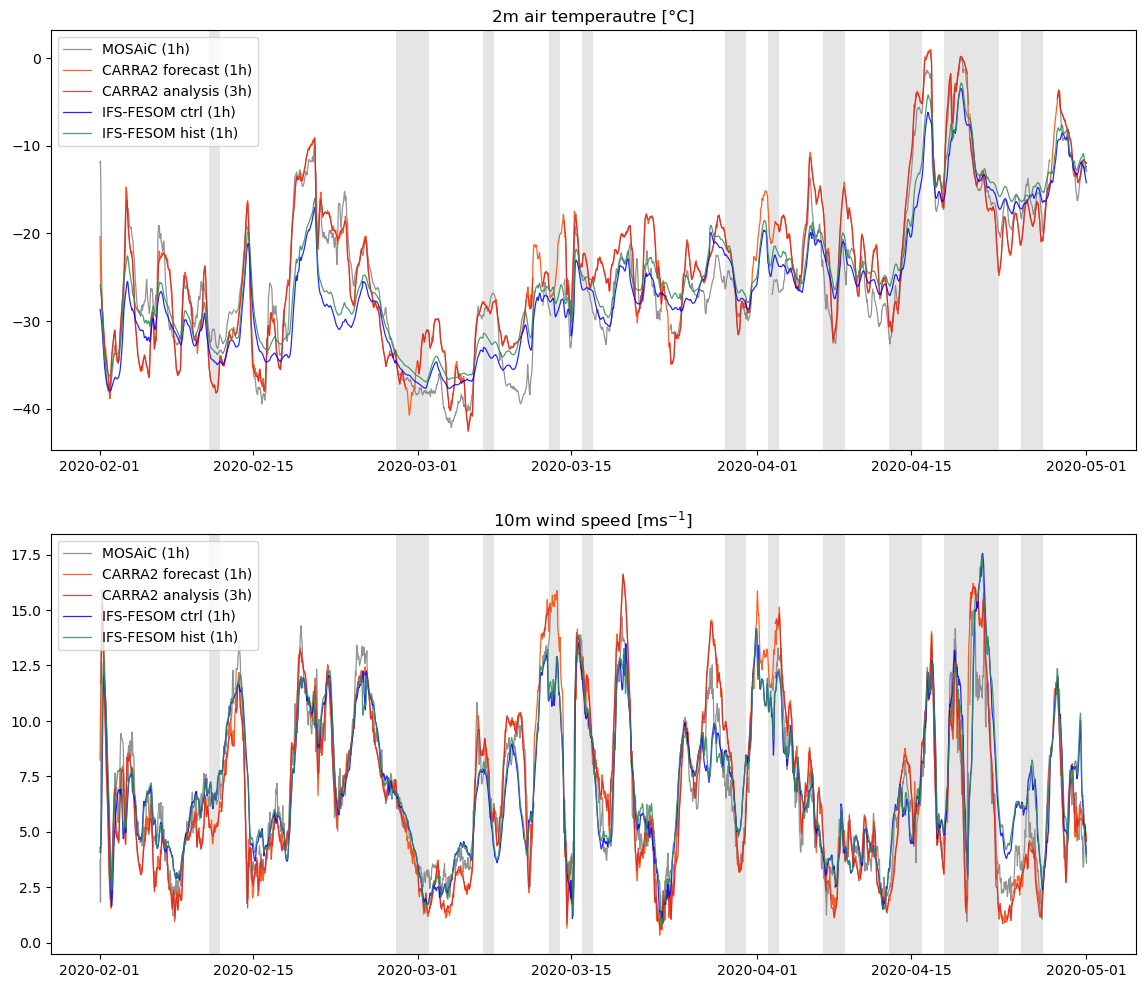

In [8]:
COLORS = {"MOSAiC": "grey", 
          "CARRA2_analysis": "tab:red", "CARRA2_forecast": "orangered",
          "IFS_hist": "seagreen", "IFS_ctrl": "blue"}
LABELS = {"MOSAiC": "MOSAiC (1h)", 
          "CARRA2_analysis": "CARRA2 analysis (3h)", "CARRA2_forecast": "CARRA2 forecast (1h)",
          "IFS_hist": "IFS-FESOM hist (1h)", "IFS_ctrl": "IFS-FESOM ctrl (1h)"}

date_str = pd.to_datetime(['20200211', '20200228', '20200229', '20200301', '20200307', '20200313',
 '20200316', '20200329', '20200330', '20200402', '20200407', '20200408',
 '20200413', '20200414', '20200415', '20200418', '20200419', '20200420',
 '20200421', '20200422', '20200425', '20200426'])

carra_series_t2m = (df_merge2.set_index('time')['CARRA2 analysis t2m'].dropna().asfreq('3h'))
carra_series_10si = (df_merge2.set_index('time')['CARRA2 analysis 10si'].dropna().asfreq('3h'))

#Plot
fig, axes = plt.subplots(2,1,figsize=(14, 12))

ax1 = axes[0]
ax1.plot(df_merge2['time'], df_merge2['MOSAiC t2m obs'], color=COLORS["MOSAiC"], lw=0.9, alpha=0.85, label=LABELS["MOSAiC"])
ax1.plot(df_merge2['time'], df_merge2['CARRA2 forecast t2m'], color=COLORS["CARRA2_forecast"], lw=0.9, alpha=0.85, label=LABELS["CARRA2_forecast"])
ax1.plot(carra_series_t2m.index, carra_series_t2m.values,color=COLORS["CARRA2_analysis"], lw=0.9, alpha=0.85,label=LABELS["CARRA2_analysis"])
ax1.plot(df_merge2['time'], df_merge2['IFS-FESOM_2t_ctrl'], color=COLORS["IFS_ctrl"], lw=0.9, alpha=0.85, label=LABELS["IFS_ctrl"])
ax1.plot(df_merge2['time'], df_merge2['IFS-FESOM_2t_hist'], color=COLORS["IFS_hist"], lw=0.9, alpha=0.85, label=LABELS["IFS_hist"])

for d in date_str:
    ax1.axvspan(d, d + pd.Timedelta(days=1), color="grey", alpha=0.2, lw=0)
ax1.legend()
ax1.set_title('2m air temperautre [°C]')

ax2 = axes[1]
ax2.plot(df_merge2['time'], df_merge2['MOSAiC 10si obs'], color=COLORS["MOSAiC"], lw=0.9, alpha=0.85, label=LABELS["MOSAiC"])
ax2.plot(df_merge2['time'], df_merge2['CARRA2 forecast 10si'], color=COLORS["CARRA2_forecast"], lw=0.9, alpha=0.85, label=LABELS["CARRA2_forecast"])
ax2.plot(carra_series_10si.index, carra_series_10si.values,color=COLORS["CARRA2_analysis"], lw=0.9, alpha=0.85,label=LABELS["CARRA2_analysis"])
ax2.plot(df_merge2['time'], df_merge2['IFS-FESOM_10si_ctrl'], color=COLORS["IFS_ctrl"], lw=0.9, alpha=0.85, label=LABELS["IFS_ctrl"])
ax2.plot(df_merge2['time'], df_merge2['IFS-FESOM_10si_hist'], color=COLORS["IFS_hist"], lw=0.9, alpha=0.85, label=LABELS["IFS_hist"])
for d in date_str:
    ax2.axvspan(d, d + pd.Timedelta(days=1), color="grey", alpha=0.2, lw=0)
ax2.legend()
ax2.set_title('10m wind speed [$\mathrm{ms}^{-1}$]')